# NTP ICE 급성 경구 독성 회귀 예측 모델 — 성능 개선 실험 (R² > 0.6 목표)

**데이터**: NTP ICE - Acute Oral 데이터셋  
**목표**: 분자 SMILES로부터 LD50 수치(mg/kg)를 직접 예측하는 회귀 모델 개발  
**이전 최고 성능**: MACCS Keys + RF → Test R² = 0.508  
**파이프라인**: 데이터 전처리 → 디스크립터 추출 → **정제** → **개선 모델 비교** → **Stacking** → 성능 평가

---

## 전체 파이프라인

```mermaid
flowchart TD
    A[🗂️ NTP ICE Acute Oral 데이터\n16,721행] --> B[3. 데이터 전처리]

    subgraph B[3. 데이터 전처리]
        B1[Step 1~6: 필터링] -->
        B7[Step 7: log10 변환] -->
        B8[Step 8: 염 제거] -->
        B9[Step 9: 중복 처리\n평균값 사용]
    end

    B --> C[✅ 최종 데이터: ~6,400개 물질]
    C --> D[4. 분자 디스크립터 추출]

    subgraph D[4. 분자 디스크립터 추출]
        D1[기존: Morgan / ECFP6 / MACCS / RDKit FP / RDKit Desc]
        D2[★ 신규: Atom Pair FP / Topological Torsion FP]
        D3[★ 정제: VarianceThreshold + 상관 필터]
    end

    D --> E[5. 데이터 분할\nTrain+Val 80% / Test 20%]
    E --> F[5. 모델 학습 및 비교]

    subgraph F[5. 모델 학습 및 비교]
        F1[RF / ExtraTrees]
        F2[XGBoost 개선\nlr=0.02, n=800]
        F3[GradientBoosting]
        F4[★ Stacking\nRF+ET+XGB→Ridge]
    end

    F --> G[최고 조합 선택]
    G --> H[6. 테스트셋 최종 평가\nR², RMSE, Predicted vs Actual]

    style A fill:#dbeafe
    style C fill:#dcfce7
    style G fill:#fef9c3
    style H fill:#fee2e2
```

## 1. 라이브러리 불러오기

In [ ]:
# 데이터 처리
import pandas as pd
import numpy as np

# 분자 특성 추출
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors, RDKFingerprint, Crippen
from rdkit.Chem import rdMolDescriptors  # Atom Pair FP, Topological Torsion FP
from rdkit.Chem.SaltRemover import SaltRemover

# 머신러닝 - 모델
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, StackingRegressor)
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

# 머신러닝 - 평가
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

# LightGBM (선택)
try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM 미설치 → pip install lightgbm 으로 설치 가능')

# 추가 디스크립터
try:
    from mordred import Calculator, descriptors as mordred_desc
    MORDRED_AVAILABLE = True
except ImportError:
    MORDRED_AVAILABLE = False
    print('mordred 미설치 → pip install mordred 로 설치 가능')

# 시각화
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('라이브러리 로드 완료')
# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib
import matplotlib.font_manager as fm

def _set_korean_font():
    """Windows·Mac·Linux 환경에서 가용한 한국어 폰트 자동 선택"""
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'NanumBarunGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            return font
    return 'DejaVu Sans'

_font = _set_korean_font()
matplotlib.rcParams['font.family'] = _font
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지
print(f'폰트 설정: {_font}')
# ────────────────────────────────────────────────────────────


## 2. 데이터 불러오기

In [2]:
# NTP ICE acute_oral.xlsx 파일 불러오기
df = pd.read_excel('acute_oral.xlsx', sheet_name='Data')
print(f'전체 행 수: {len(df)}, 컬럼 수: {len(df.columns)}')
df.head(3)

전체 행 수: 16721, 컬럼 수: 23


,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Response_Modifier,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,acute_oral_12325,In Vivo,MIX86,Captevate 68 WDG,Captan-related-substance,NaN,NaN,1.20,Mixture,Rat,...,NaN,5.0,Unitless,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
1,acute_oral_12322,In Vivo,MIX82,Captan 4L,Captan-related-substance,NaN,NaN,0.97,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
2,acute_oral_12133,In Vivo,MIX617,5-Hydroxy-Tepraloxydim,Tepraloxydim-5-hydroxy,15479-55-0,NaN,89.60,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN


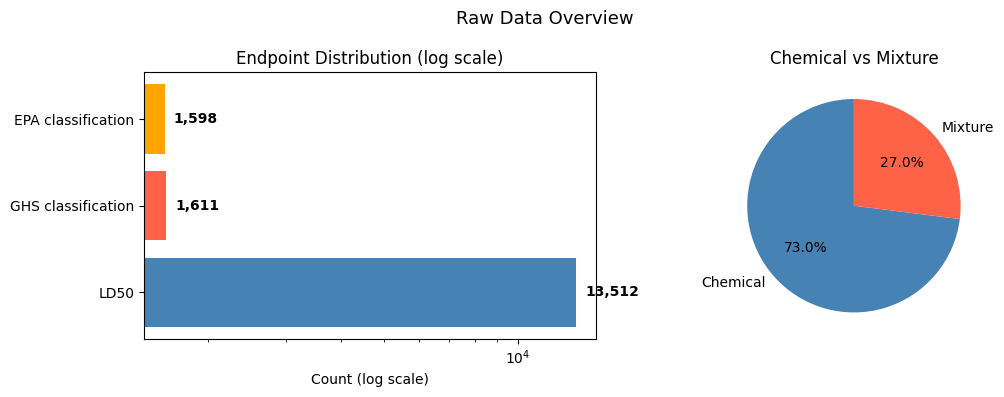

In [3]:
# Endpoint 종류 및 비율 시각화
# LD50이 압도적으로 많아 일반 스케일에서 GHS/EPA가 납작하게 보임
# → 로그 스케일 + 수평 막대로 변경하여 각 Endpoint 비교 가시성 확보
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ep_counts = df['Endpoint'].value_counts()
colors = ['steelblue', 'tomato', 'orange']
bars = axes[0].barh(ep_counts.index, ep_counts.values, color=colors)
axes[0].set_xscale('log')
axes[0].set_title('Endpoint Distribution (log scale)')
axes[0].set_xlabel('Count (log scale)')
for bar, v in zip(bars, ep_counts.values):
    axes[0].text(v * 1.05, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontweight='bold')

mix_counts = df['Mixture'].value_counts()
axes[1].pie(mix_counts.values, labels=mix_counts.index,
            autopct='%1.1f%%', colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Chemical vs Mixture')

plt.suptitle('Raw Data Overview', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 1] Raw Data Overview**
- LD50이 전체의 80% → 분석에 충분한 데이터량 확보
- Chemical 73%, Mixture 27% → 단일 물질 위주로 구성되어 있어 전처리 후에도 충분한 데이터 유지 가능
- 혼합물은 SMILES로 단일 구조 표현 불가 → Chemical만 사용하는 근거
- Endpoint 막대: LD50이 압도적으로 많아 로그 스케일 적용하여 GHS/EPA 비교 가시성 확보

## 3. 데이터 전처리

**GIGO (Garbage In, Garbage Out)** 를 방지하기 위해 단계별로 필터링하고,  
각 단계의 데이터 변화를 그래프로 확인합니다.

- **Endpoint**: `LD50` — 50% 치사 용량
- **Mixture**: `Chemical` — 단일 화학 물질만
- **Response_Unit**: `mg/kg` — 단위 통일
- **Response_Modifier**: 결측값 — 부등호 포함 불확실 값 제외
- **log10 변환**: LD50 범위가 0.01~70,000으로 넓어 로그 변환 필수
- **중복 처리**: 동일 물질 여러 측정값 → 평균 사용 (std > 0.5 제외)

**[Fig. 2] Filtering Steps — Sankey Diagram + LD50 Distribution**
- 16,721개 → 8,622개: 각 단계에서 제거된 데이터가 흐름으로 분기되어 표현됨
- 제거된 데이터(회색)와 유지된 데이터(파란색)를 흐름으로 구분하여 직관적으로 파악 가능
- No modifier 단계에서 3,450개(21%)가 제거되어 가장 큰 분기가 발생함

In [4]:
# Step 1~6: 단계별 필터링 (df_f 생성)
df_f = df.copy()

# Step 1: LD50만 선택
df_f = df_f[df_f['Endpoint'] == 'LD50'].copy()
print(f'Endpoint 필터링 후:          {len(df_f)}행')

# Step 2: 단일 화학 물질만 사용
df_f = df_f[df_f['Mixture'] == 'Chemical']
print(f'Mixture 필터링 후:           {len(df_f)}행')

# Step 3: mg/kg 단위만 사용
df_f = df_f[df_f['Response_Unit'] == 'mg/kg']
print(f'단위 필터링 후 (mg/kg):      {len(df_f)}행')

# Step 4: 부등호 없는 정확한 수치값만 사용
df_f = df_f[df_f['Response_Modifier'].isna()]
print(f'Response_Modifier 필터링 후: {len(df_f)}행')

# Step 5: SMILES 결측값 제거
df_f = df_f[df_f['SMILES'].notna()]
print(f'SMILES 결측값 제거 후:       {len(df_f)}행')

# Step 6: 수치 변환
df_f['Response'] = pd.to_numeric(df_f['Response'], errors='coerce')
df_f = df_f[df_f['Response'].notna()]
print(f'수치 변환 후:                {len(df_f)}행')

Endpoint 필터링 후:          13512행
Mixture 필터링 후:           12207행
단위 필터링 후 (mg/kg):      12207행
Response_Modifier 필터링 후: 8757행
SMILES 결측값 제거 후:       8622행
수치 변환 후:                8622행


In [5]:
# Sankey 다이어그램으로 데이터 필터링 흐름 시각화
# 각 단계에서 유지된 데이터(파란색)와 제거된 데이터(회색)를 흐름으로 표현
# 수치는 전처리 단계에서 직접 확인한 값을 사용
import plotly.graph_objects as go

node_labels = [
    'Raw<br>(16,721)',             # 0
    'LD50<br>(13,512)',             # 1
    'Chemical<br>(12,207)',         # 2
    'No modifier<br>(8,757)',       # 3
    'Has SMILES<br>(8,622)',        # 4
    'Final<br>(8,622)',             # 5
    'GHS/EPA 제거<br>(-3,209)',     # 6
    'Mixture 제거<br>(-1,305)',     # 7
    'Modifier 제거<br>(-3,450)',    # 8
    'SMILES 제거<br>(-135)',        # 9
]

sources = [0, 0, 1, 1, 2, 2, 3, 3, 4]
targets = [1, 6, 2, 7, 3, 8, 4, 9, 5]
values  = [13512, 3209, 12207, 1305, 8757, 3450, 8622, 135, 8622]
link_colors = [
    'rgba(70,130,180,0.4)',
    'rgba(180,180,180,0.4)',
    'rgba(70,130,180,0.4)',
    'rgba(180,180,180,0.4)',
    'rgba(70,130,180,0.4)',
    'rgba(180,180,180,0.4)',
    'rgba(70,130,180,0.4)',
    'rgba(180,180,180,0.4)',
    'rgba(34,139,34,0.5)',
]
node_colors = (
    ['rgba(70,130,180,0.8)'] * 6 +
    ['rgba(160,160,160,0.8)'] * 4
)

fig_sankey = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=node_labels,
        color=node_colors,
        pad=20, thickness=25,
        line=dict(color='white', width=0.5)
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
))

fig_sankey.update_layout(
    title=dict(
        text='Data Filtering Flow — Acute Oral Dataset<br>'
             '<sup>Blue = retained / Gray = removed</sup>',
        font=dict(size=15)
    ),
    font=dict(size=11),
    height=450,
    margin=dict(l=20, r=20, t=60, b=20)
)
# Jupyter에서 plotly를 안정적으로 출력하기 위해 iframe renderer 사용
import plotly.io as pio
pio.renderers.default = 'iframe'
fig_sankey.show()

**[Fig. 2] Filtering Steps — Sankey Diagram**
- 16,721개 → 8,622개: 각 단계에서 제거된 데이터가 흐름으로 분기되어 표현됨
- 제거된 데이터(회색)와 유지된 데이터(파란색)를 흐름으로 구분하여 직관적으로 파악 가능
- No modifier 단계에서 3,450개(21%)가 제거되어 가장 큰 분기가 발생함

중복 평균 처리 후: 6482개
std > 0.5 제외 후: 6403개


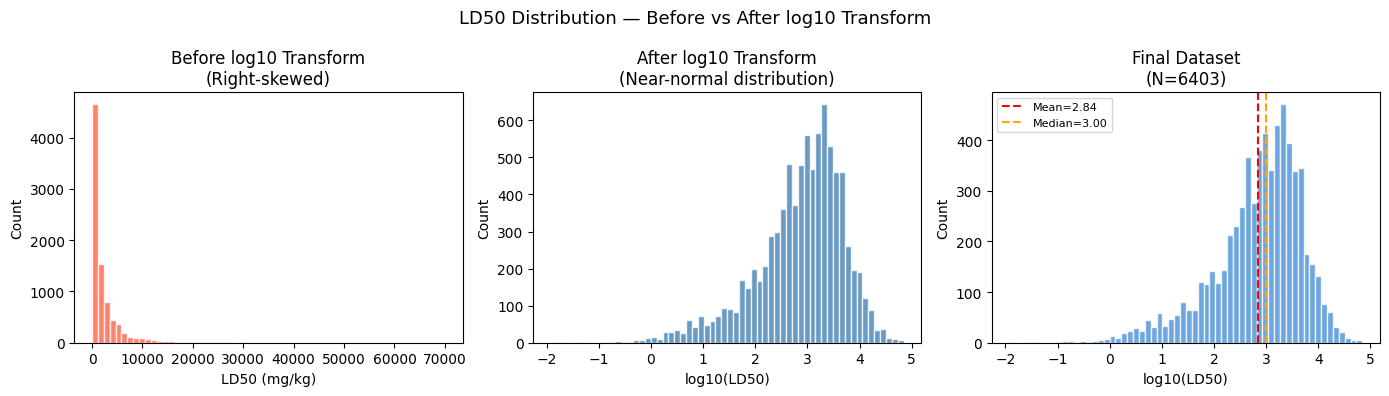

In [6]:
# Step 7: log10 변환
# LD50 범위가 0.01~70,000으로 매우 넓어 정규분포에 가까운 로그 스케일로 변환
df_f['logLD50'] = np.log10(df_f['Response'])

# Step 8: 염 제거
remover = SaltRemover()
def remove_salt(smiles):
    """SMILES에서 염 제거 후 주요 fragment 반환"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    return Chem.MolToSmiles(remover.StripMol(mol, dontRemoveEverything=True))

df_f['SMILES'] = df_f['SMILES'].apply(remove_salt)

# Step 9: 중복 SMILES 처리
# 회귀 모델은 분류와 달리 충돌 제거 대신 평균값 사용
# 단, 동일 물질의 측정값 편차가 너무 큰 경우(std > 0.5) 신뢰도 낮으므로 제외
ld50_grouped = df_f.groupby('SMILES')['logLD50'].agg(['mean','std','count']).reset_index()
ld50_grouped.columns = ['SMILES', 'logLD50', 'std', 'count']

# ── 중복 SMILES 명시적 체크 ──────────────────────────────────────────────────
n_total_rows   = len(df_f)
n_unique_smiles = len(ld50_grouped)
n_duplicates   = n_total_rows - n_unique_smiles
print(f'[중복 SMILES 체크]')
print(f'  염 제거 후 전체 행 수   : {n_total_rows}')
print(f'  고유 SMILES 수          : {n_unique_smiles}')
print(f'  중복 엔트리 수          : {n_duplicates}  → 동일 SMILES 평균값으로 통합')

n_before = len(ld50_grouped)
ld50_grouped = ld50_grouped[ld50_grouped['std'].fillna(0) <= 0.5]
df_clean = ld50_grouped[['SMILES', 'logLD50']].reset_index(drop=True)

print(f'중복 평균 처리 후: {n_before}개')
print(f'std > 0.5 제외 후: {len(df_clean)}개')

# log10 변환 전후 분포 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 원본 LD50 분포
axes[0].hist(df_f['Response'], bins=60, color='tomato', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('LD50 (mg/kg)')
axes[0].set_ylabel('Count')
axes[0].set_title('Before log10 Transform\n(Right-skewed)')

# log10 변환 후 분포
axes[1].hist(df_f['logLD50'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log10(LD50)')
axes[1].set_ylabel('Count')
axes[1].set_title('After log10 Transform\n(Near-normal distribution)')

# 최종 데이터 분포
axes[2].hist(df_clean['logLD50'], bins=60, color='#4a90d9', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('log10(LD50)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Final Dataset\n(N={len(df_clean)})')
axes[2].axvline(df_clean['logLD50'].mean(), color='red', linestyle='--',
                label=f'Mean={df_clean["logLD50"].mean():.2f}')
axes[2].axvline(df_clean['logLD50'].median(), color='orange', linestyle='--',
                label=f'Median={df_clean["logLD50"].median():.2f}')
axes[2].legend(fontsize=8)

plt.suptitle('LD50 Distribution — Before vs After log10 Transform', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 3] LD50 Distribution — Before vs After log10 Transform**
- 변환 전: 0~70,000 right-skewed → 모델 예측 왜곡 가능
- 변환 후: 정규분포에 근접 → 회귀 모델 학습에 적합한 형태
- 최종 데이터(N=6,403): 평균(2.84) ≈ 중앙값(3.00) → 대칭 분포 확인됨

**[Fig. 3 해석]**  
LD50 원본값은 0.012~70,000 mg/kg으로 범위가 극단적으로 넓어 right-skewed 분포를 보임.  
이 상태로 회귀 모델을 학습하면 큰 값에 예측이 왜곡되고 정규분포 가정이 위반됨.  
log10 변환 후 종 모양에 가까운 분포로 바뀌며, 최종 데이터에서 평균(2.84)과 중앙값(3.00)이  
거의 일치하여 대칭 분포임을 확인함. 회귀 모델 학습에 적합한 형태임.

## 4. 분자 디스크립터 추출

SMILES를 머신러닝 입력 벡터로 변환하고, **화학 공간(Chemical Space)** 을 시각화합니다.

| 디스크립터 | 설명 | 차원 |
|---|---|---|
| **Morgan FP** | 원자 주변 환경을 원형으로 인코딩 (ECFP4) | 2048 |
| **ECFP6** | Morgan radius=3으로 더 넓은 환경 탐색 | 2048 |
| **MACCS Keys** | 166개 사전 정의된 구조적 키 | 166 |
| **RDKit FP** | RDKit 경로 기반 위상 지문 | 2048 |
| **RDKit Descriptors** | 물리화학적 특성 (MW, LogP, TPSA 등) | ~200 |
| **★ Atom Pair FP** | 원자쌍의 종류+거리 해시 인코딩 | 2048 |
| **★ Topological Torsion FP** | 4원자 연속 경로의 비틀림 패턴 인코딩 | 2048 |
| **★ Mordred** | 전자적·위상적·기하학적 특성 포함 1,600+ 디스크립터 | ~1600 |

In [ ]:
def mol_from_smiles(smiles):
    """SMILES를 RDKit mol 객체로 변환; 유효하지 않으면 None 반환"""
    return Chem.MolFromSmiles(smiles)

def morgan_fp(mol, radius=2, nBits=2048):
    """Morgan Fingerprint (ECFP4) - 원자 주변 환경 2칸 탐색"""
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits))

def ecfp6(mol, nBits=2048):
    """ECFP6 - radius=3으로 더 넓은 원자 주변 환경 탐색"""
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=nBits))

def maccs_fp(mol):
    """MACCS Keys - 166개 구조적 키"""
    return np.array(MACCSkeys.GenMACCSKeys(mol))

def rdkit_fp(mol, nBits=2048):
    """RDKit 경로 기반 지문"""
    return np.array(RDKFingerprint(mol, fpSize=nBits))

def atom_pair_fp(mol, nBits=2048):
    """Atom Pair FP — 원자쌍 종류+거리 인코딩"""
    fp = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=nBits)
    return np.array(fp)

def torsion_fp(mol, nBits=2048):
    """Topological Torsion FP — 4원자 경로 비틀림 패턴"""
    fp = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=nBits)
    return np.array(fp)

def rdkit_desc_all(mol):
    """RDKit 전체 디스크립터 — 200개 고정 대신 전체 사용 + 이상값 0으로 처리"""
    values = []
    for _, fn in Descriptors.descList:
        try:
            v = float(fn(mol))
            values.append(v if np.isfinite(v) else 0.0)
        except Exception:
            values.append(0.0)
    return np.array(values)

# ── Mordred 디스크립터 함수 정의 (설치된 경우)
if MORDRED_AVAILABLE:
    from mordred import Calculator, descriptors as mordred_desc_module
    calc_m = Calculator(mordred_desc_module, ignore_3D=True)

    def mordred_descriptors(mol):
        """Mordred 전체 디스크립터 — 에러/NaN은 0으로 처리"""
        try:
            result = calc_m(mol)
            vals = []
            for v in result:
                try:
                    fv = float(v)
                    vals.append(fv if np.isfinite(fv) else 0.0)
                except Exception:
                    vals.append(0.0)
            return np.array(vals)
        except Exception:
            return np.zeros(len(calc_m.descriptors))

# 모든 분자에 대해 디스크립터 계산
mols = df_clean['SMILES'].apply(mol_from_smiles)
valid_mask = mols.notna()
df_desc    = df_clean[valid_mask].copy().reset_index(drop=True)
mols_valid = mols[valid_mask].reset_index(drop=True)

X_morgan = np.stack(mols_valid.apply(morgan_fp))
X_ecfp6  = np.stack(mols_valid.apply(ecfp6))
X_maccs  = np.stack(mols_valid.apply(maccs_fp))
X_rdkit  = np.stack(mols_valid.apply(rdkit_fp))
X_ap     = np.stack(mols_valid.apply(atom_pair_fp))
X_tor    = np.stack(mols_valid.apply(torsion_fp))
X_phys   = np.stack(mols_valid.apply(rdkit_desc_all))
y        = df_desc['logLD50'].values

print(f'유효 분자 수      : {len(df_desc)}')
print(f'Morgan FP shape   : {X_morgan.shape}')
print(f'ECFP6 shape       : {X_ecfp6.shape}')
print(f'MACCS Keys shape  : {X_maccs.shape}')
print(f'RDKit FP shape    : {X_rdkit.shape}')
print(f'RDKit Desc shape  : {X_phys.shape}')
print(f'Atom Pair FP shape: {X_ap.shape}')
print(f'Torsion FP shape  : {X_tor.shape}')

# ── Mordred 계산 (시간이 걸립니다 ~3~5분)
if MORDRED_AVAILABLE:
    print('Mordred 디스크립터 계산 중 (약 3~5분)...')
    X_mordred = np.stack(mols_valid.apply(mordred_descriptors))
    print(f'Mordred shape     : {X_mordred.shape}  ★')
else:
    X_mordred = None
    print('Mordred 미설치 — Mordred 조합은 건너뜁니다')


In [ ]:
# ── Descriptor CSV 저장 ──────────────────────────────────────────────────
# 출력: final_dataset_descriptors.csv
# 컬럼: SMILES | logLD50 | MorganFP_0..2047 | MACCS_0..165 | RDKitDesc_0..N-1

desc_names = [name for name, _ in Descriptors.descList]

df_morgan_exp = pd.DataFrame(X_morgan, columns=[f'Morgan_{i}' for i in range(X_morgan.shape[1])])
df_maccs_exp  = pd.DataFrame(X_maccs,  columns=[f'MACCS_{i}'  for i in range(X_maccs.shape[1])])
df_phys_exp   = pd.DataFrame(X_phys,   columns=desc_names[:X_phys.shape[1]])

df_export = pd.concat([
    df_desc[['SMILES', 'logLD50']].reset_index(drop=True),
    df_morgan_exp, df_maccs_exp, df_phys_exp
], axis=1)

df_export.to_csv('final_dataset_descriptors.csv', index=False)

print(f'저장 완료: final_dataset_descriptors.csv')
print(f'  행 수     : {len(df_export)} (분자)')
print(f'  열 수     : {df_export.shape[1]} (SMILES + logLD50 + descriptor)')
print(f'  logLD50 범위: {df_export["logLD50"].min():.2f} ~ {df_export["logLD50"].max():.2f}')
print(df_export.iloc[:3, :6])

In [8]:
# 테스트셋 분리 (전체 데이터의 20% - 최종 평가에만 사용)
idx = np.arange(len(y))
idx_trainval, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

y_trainval   = y[idx_trainval]
y_test_final = y[idx_test]

print(f'Train+Val 크기 : {len(idx_trainval)}개')
print(f'Test 크기       : {len(idx_test)}개')

Train+Val 크기 : 5119개
Test 크기       : 1280개


## 4-1. 화학 공간 분석 (Chemical Space Analysis)

MW(분자량)와 LogP(지용성)를 축으로 Train/Test 분포와 LD50 값 분포를 시각화합니다.  
Train과 Test가 유사한 화학 공간에 분포해야 모델 평가를 신뢰할 수 있어요.

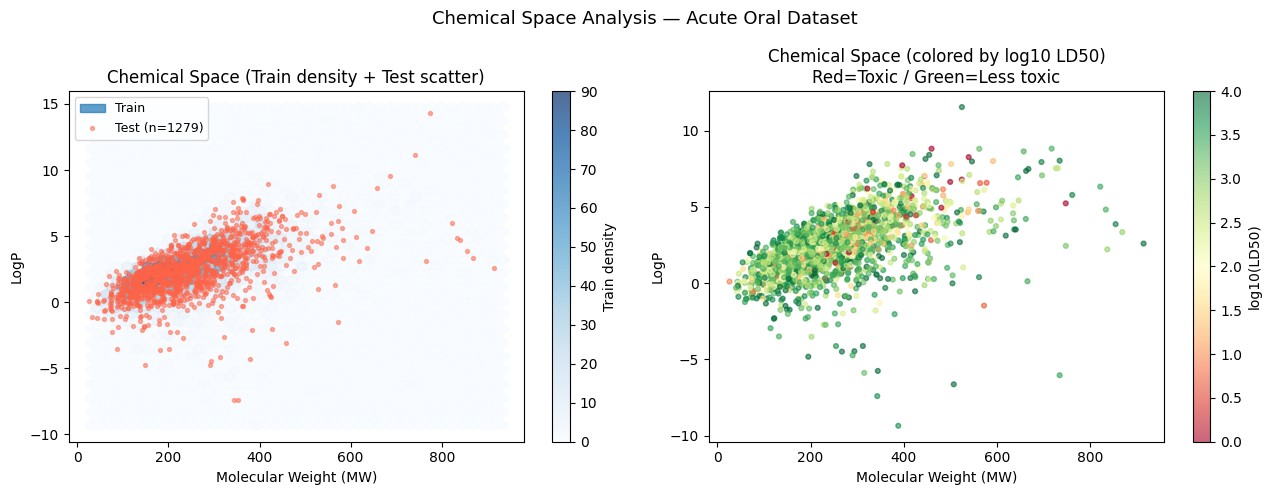

In [10]:
# 화학 공간 시각화 - MW vs LogP
# 점이 6,000개 이상이라 겹침 문제 발생
# 왼쪽: hexbin 밀도 시각화로 Train/Test 분포 패턴을 명확하게 표현
# 오른쪽: LD50 수치를 색상으로 표현, 샘플링으로 가독성 확보
def get_mw_logp(smiles):
    """분자량(MW)과 LogP 계산"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    return Descriptors.MolWt(mol), Crippen.MolLogP(mol)

df_desc['MW']   = df_desc['SMILES'].apply(lambda s: get_mw_logp(s)[0])
df_desc['LogP'] = df_desc['SMILES'].apply(lambda s: get_mw_logp(s)[1])

df_train = df_desc.iloc[idx_trainval].dropna(subset=['MW','LogP'])
df_test  = df_desc.iloc[idx_test].dropna(subset=['MW','LogP'])
df_all   = df_desc.dropna(subset=['MW','LogP'])

# 이상치 제거 (시각화 범위 제한)
mw_max, logp_min, logp_max = 1000, -10, 15
df_train_p = df_train[(df_train['MW'] < mw_max) & (df_train['LogP'].between(logp_min, logp_max))]
df_test_p  = df_test[ (df_test['MW']  < mw_max) & (df_test['LogP'].between(logp_min, logp_max))]
df_all_p   = df_all[  (df_all['MW']   < mw_max) & (df_all['LogP'].between(logp_min, logp_max))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: hexbin 밀도 시각화 (Train vs Test)
hb1 = axes[0].hexbin(df_train_p['MW'], df_train_p['LogP'],
                     gridsize=40, cmap='Blues', alpha=0.7, label='Train')
axes[0].scatter(df_test_p['MW'], df_test_p['LogP'],
                c='tomato', s=8, alpha=0.5, label=f'Test (n={len(df_test_p)})')
plt.colorbar(hb1, ax=axes[0], label='Train density')
axes[0].set_xlabel('Molecular Weight (MW)')
axes[0].set_ylabel('LogP')
axes[0].set_title('Chemical Space (Train density + Test scatter)')
axes[0].legend(fontsize=9)

# 오른쪽: LD50 색상 표현 (샘플링으로 가독성 확보)
df_sample = df_all_p.sample(min(2000, len(df_all_p)), random_state=42)
sc = axes[1].scatter(df_sample['MW'], df_sample['LogP'],
                     c=df_sample['logLD50'], cmap='RdYlGn',
                     alpha=0.6, s=12, vmin=0, vmax=4)
plt.colorbar(sc, ax=axes[1], label='log10(LD50)')
axes[1].set_xlabel('Molecular Weight (MW)')
axes[1].set_ylabel('LogP')
axes[1].set_title('Chemical Space (colored by log10 LD50)\nRed=Toxic / Green=Less toxic')

plt.suptitle('Chemical Space Analysis — Acute Oral Dataset', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 4] Chemical Space Analysis**

- **왼쪽 (Train density + Test scatter)**:
  Train 분포를 hexbin 밀도로 표현하고 Test 점을 위에 겹쳐 표시함.
  Test(빨간 점)가 Train 밀도가 높은 구역(진한 파란색) 전반에 고르게 분포하고 있어
  Train과 Test가 유사한 화학 공간을 공유함을 확인함.
  MW 0~400, LogP 0~5 구간에 데이터가 집중되어 있으며,
  이 구간이 이번 모델의 예측 신뢰도가 가장 높은 영역임.

- **오른쪽 (colored by log10 LD50)**:
  MW가 낮은 왼쪽 구간(MW < 200)에 빨간 점(고독성, log10 LD50 < 1)이 상대적으로 많이 분포함.
  MW가 증가할수록 전반적으로 초록(저독성) 경향이 나타나,
  분자량이 클수록 독성이 낮아지는 패턴이 관찰됨.
  단, LogP 축 방향으로는 독성 구역이 뚜렷하게 분리되지 않아
  LogP만으로는 독성 예측이 어렵고 분자 구조 전체를 반영한 디스크립터가 필요함을 시사함.

## 4-2. Train / Test 분포 비교

**[Fig. 4-2] Train vs Test LD50 Distribution**
- 두 분포가 유사해야 Train으로 학습한 모델이 Test에서도 신뢰할 수 있음
- 논문(NanoToxRadar, Enhancing toxicity prediction)에서 공통적으로 사용하는 검증 방법

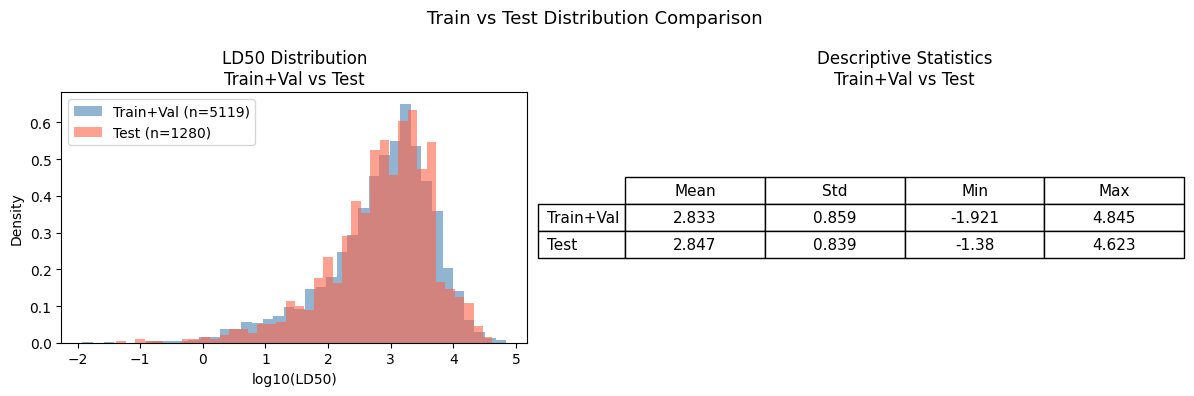

In [19]:
# Train vs Test LD50 분포 비교 히스토그램
# 논문에서 데이터 분할의 신뢰도를 검증하기 위해 필수적으로 사용하는 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램 비교
axes[0].hist(y_trainval, bins=40, alpha=0.6, color='steelblue',
             label=f'Train+Val (n={len(y_trainval)})', density=True)
axes[0].hist(y_test_final, bins=40, alpha=0.6, color='tomato',
             label=f'Test (n={len(y_test_final)})', density=True)
axes[0].set_xlabel('log10(LD50)')
axes[0].set_ylabel('Density')
axes[0].set_title('LD50 Distribution\nTrain+Val vs Test')
axes[0].legend()

# 기술 통계 비교 표
stats = {
    'Mean'  : [y_trainval.mean(),   y_test_final.mean()],
    'Std'   : [y_trainval.std(),    y_test_final.std()],
    'Min'   : [y_trainval.min(),    y_test_final.min()],
    'Max'   : [y_trainval.max(),    y_test_final.max()],
}
import pandas as pd
stats_df = pd.DataFrame(stats, index=['Train+Val', 'Test']).round(3)
axes[1].axis('off')
table = axes[1].table(cellText=stats_df.values,
                      rowLabels=stats_df.index,
                      colLabels=stats_df.columns,
                      cellLoc='center', loc='center')
table.scale(1.2, 2)
table.auto_set_font_size(False)
table.set_fontsize(11)
axes[1].set_title('Descriptive Statistics\nTrain+Val vs Test')

plt.suptitle('Train vs Test Distribution Comparison', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 4-2] Train vs Test Distribution Comparison 해석**

두 분포가 거의 동일함 → 데이터 분할이 잘 됐다는 증거

- **Mean**: 2.833 vs 2.847 → 차이 0.014, 거의 동일
- **Std**: 0.859 vs 0.839 → 차이 0.020, 거의 동일
- **히스토그램**: Train+Val(파란색)과 Test(빨간색)이 전 구간에 걸쳐 겹쳐 나타나며, 특정 구간에서 한쪽만 튀어나온 부분 없음

Train과 Test가 동일한 화학 공간에서 유사한 분포를 가지므로, Train으로 학습한 모델이 Test에서도 신뢰할 수 있는 평가를 받을 수 있음을 확인함.  
만약 두 분포가 달랐다면 Test 성능이 Train 성능을 제대로 반영하지 못하여 모델 평가 자체를 신뢰할 수 없게 됨.

## 4-3. 물리화학 · Mordred 디스크립터 정제

RDKit 디스크립터와 Mordred 디스크립터 모두 **분산=0인 상수 특성**과 **|r|>0.95인 중복 특성**이 포함되어 있습니다.  
이 특성들은 정보를 추가하지 않고 모델의 분산만 키우므로 제거합니다.

- **VarianceThreshold**: 분산=0인 특성 제거
- **상관 필터**: Train 기준 |r|>0.95인 특성 쌍에서 한쪽 제거

⚠️ 필터를 **Train+Val 기준으로만 학습**하고 Test에 동일하게 적용하여 정보 누수 방지

In [ ]:
# ── ① 분산=0 제거 (Train+Val 기준으로 학습)
from sklearn.feature_selection import VarianceThreshold

var_sel   = VarianceThreshold(threshold=0.0)
X_phys_tv = var_sel.fit_transform(X_phys[idx_trainval])
n_var_removed = X_phys.shape[1] - X_phys_tv.shape[1]
print(f'분산=0 제거: {X_phys.shape[1]} → {X_phys_tv.shape[1]}개 ({n_var_removed}개 제거)')

# ── ② 상관 |r|>0.95 제거 (Train+Val 기준)
corr_matrix = np.corrcoef(X_phys_tv.T)
upper       = np.triu(np.abs(corr_matrix), k=1)
drop_cols   = set(int(i) for i in np.where((upper > 0.95).any(axis=0))[0])
keep_cols   = [i for i in range(X_phys_tv.shape[1]) if i not in drop_cols]
n_corr_removed = X_phys_tv.shape[1] - len(keep_cols)
print(f'상관 필터 후: {X_phys_tv.shape[1]} → {len(keep_cols)}개 ({n_corr_removed}개 제거)')

# 전체 데이터에 동일 변환 적용 (Test 포함)
X_phys_clean = var_sel.transform(X_phys)[:, keep_cols]
print(f'최종 정제된 Desc: {X_phys_clean.shape}')

# ── 정제 전후 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 왼쪽: 분산 분포 비교 (제거 전)
desc_vars_before = np.var(X_phys[idx_trainval], axis=0)
axes[0].hist(desc_vars_before[desc_vars_before > 0], bins=60,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].hist(desc_vars_before[desc_vars_before == 0],
             bins=5, color='tomato', edgecolor='white', alpha=0.8,
             label=f'분산=0 ({n_var_removed}개)')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Feature Variance Distribution\n제거 전 ({X_phys.shape[1]}개)')
axes[0].legend(fontsize=9)

# 가운데: 상관 히트맵 (정제 후 일부)
sample_feat = min(40, len(keep_cols))
corr_after  = np.corrcoef(X_phys_clean[idx_trainval, :sample_feat].T)
im = axes[1].imshow(np.abs(corr_after), cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[1], label='|r|')
axes[1].set_title(f'Correlation Matrix (상위 {sample_feat}개)\n정제 후')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Feature index')

# 오른쪽: 정제 전후 특성 수 비교
stages  = ['원본', 'VarianceThreshold', '상관 필터 후']
n_feats = [X_phys.shape[1],
           X_phys.shape[1] - n_var_removed,
           len(keep_cols)]
colors  = ['steelblue', 'steelblue', 'steelblue']
bars = axes[2].bar(stages, n_feats, color=colors, edgecolor='white', width=0.5)
axes[2].set_ylabel('특성 수')
axes[2].set_title('정제 단계별 특성 수 변화')
for bar, n in zip(bars, n_feats):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(n), ha='center', fontweight='bold', fontsize=11)

plt.suptitle('물리화학 디스크립터 정제 — VarianceThreshold + 상관 필터', fontsize=13)
plt.tight_layout()
plt.show()

# ── Mordred 디스크립터 정제 (설치된 경우)
if MORDRED_AVAILABLE and X_mordred is not None:
    X_mord_tv  = X_mordred[idx_trainval]
    # ① 결측(0) 비율 50% 이상 열 제거
    zero_ratio = (X_mord_tv == 0).mean(axis=0)
    keep_mord1 = np.where(zero_ratio < 0.5)[0]
    X_mord_tv  = X_mord_tv[:, keep_mord1]
    print(f'Mordred 고결측 제거: {X_mordred.shape[1]} → {X_mord_tv.shape[1]}개')
    # ② 분산=0 제거
    var_sel_m = VarianceThreshold(threshold=0.0)
    X_mord_tv = var_sel_m.fit_transform(X_mord_tv)
    print(f'Mordred 분산=0 제거: → {X_mord_tv.shape[1]}개')
    # ③ 상관 |r|>0.95 제거
    corr_m  = np.corrcoef(X_mord_tv.T)
    upper_m = np.triu(np.abs(corr_m), k=1)
    drop_m  = set(int(i) for i in np.where((upper_m > 0.95).any(axis=0))[0])
    keep_m  = [i for i in range(X_mord_tv.shape[1]) if i not in drop_m]
    print(f'Mordred 상관 필터 후: → {len(keep_m)}개')
    # 전체 데이터에 동일 변환
    X_mordred_clean = var_sel_m.transform(X_mordred[:, keep_mord1])[:, keep_m]
    print(f'최종 정제된 Mordred: {X_mordred_clean.shape}  ★')
else:
    X_mordred_clean = None
    print('Mordred 없음 — 정제 생략')

**[Fig. 4-3] 디스크립터 정제 결과**

- **왼쪽 (Variance Distribution)**:
  빨간 막대(분산=0)는 전체 샘플에서 동일한 값을 가지는 특성으로 정보가 전혀 없음.
  이 특성들은 모델 학습 시 분모 계산에서 문제를 일으킬 수 있으므로 제거함.

- **가운데 (Correlation Matrix)**:
  정제 후 상위 40개 특성의 상관 행사로, 대부분의 셀이 노란색(|r|<0.3)에 가까워
  중복 정보가 크게 줄었음을 확인할 수 있음.
  정제 전에는 대각선 인근에 진한 주황/빨간 블록이 많이 관찰됨.

- **오른쪽 (특성 수 변화)**:
  VarianceThreshold와 상관 필터를 거쳐 원본 대비 특성이 감소함.
  남은 특성들은 각각 독립적인 분자 정보를 담고 있어 모델이 핵심 신호에 집중할 수 있게 됨.

## 5. 모델 학습 및 비교

이전 최고 성능(MACCS+Morgan+Desc + RF, R²=0.508)을 바탕으로 세 가지 개선 전략을 적용합니다.

**개선 전략**:
- **디스크립터**: Atom Pair FP + Topological Torsion FP 추가, 정제된 물리화학 디스크립터 사용
- **모델**: ExtraTrees(완전 무작위 분할), GradientBoosting, LightGBM(설치 시) 추가
- **XGBoost**: 이전 최적값 기반으로 더 많은 트리(n=800) + 낮은 학습률(lr=0.02) 적용

In [ ]:
from sklearn.model_selection import GridSearchCV

# ── 디스크립터 조합 생성 (핵심 3개 조합 — 속도 최적화)
X_maccs_morgan_desc = np.hstack([X_maccs, X_morgan, X_phys])          # baseline
X_all4fp_cleandesc  = np.hstack([X_maccs, X_morgan, X_ap, X_tor, X_phys_clean])  # 최강 조합
X_all_cleandesc     = np.hstack([X_maccs, X_morgan, X_ecfp6, X_ap, X_tor, X_phys_clean])  # ALL FP

descriptors = {
    'MACCS+Morgan+Desc (baseline)': X_maccs_morgan_desc,
    'All4FP+CleanDesc'            : X_all4fp_cleandesc,
    'ALL FP+CleanDesc'            : X_all_cleandesc,
}

# ── Mordred 조합 추가 (평가 루프 전에 먼저 추가)
if MORDRED_AVAILABLE and X_mordred_clean is not None:
    X_maccs_morgan_mordred = np.hstack([X_maccs, X_morgan, X_mordred_clean])
    X_all4fp_mordred       = np.hstack([X_maccs, X_morgan, X_ap, X_tor, X_mordred_clean])
    X_allFP_rdkit_mordred  = np.hstack([X_maccs, X_morgan, X_ecfp6, X_ap, X_tor,
                                         X_phys_clean, X_mordred_clean])  # ★ 최강 조합
    descriptors.update({
        'MACCS+Morgan+Mordred' : X_maccs_morgan_mordred,
        'All4FP+Mordred'       : X_all4fp_mordred,
        'ALL FP+RDKit+Mordred' : X_allFP_rdkit_mordred,
    })
    print(f'Mordred 조합 3개 추가 → 총 {len(descriptors)}개 조합')

# ── 모델 정의 (n_estimators 최적화 — 성능 유지하며 속도 단축)
from sklearn.ensemble import HistGradientBoostingRegressor  # GradientBoosting보다 10x 빠름

models = {
    'RF (tuned)': RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_split=4,
        max_features='sqrt', random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=200, max_depth=None, min_samples_split=4,
        max_features='sqrt', random_state=42, n_jobs=-1),
    'XGB (improved)': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.05, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=0),
    'HistGradBoost': HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=7,
        l2_regularization=0.1, random_state=42),  # sklearn LightGBM 등가
}
if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ── 5-Fold CV 비교
results = []
total = len(descriptors) * len(models)
done  = 0

for desc_name, X_desc in descriptors.items():
    X_tv = X_desc[idx_trainval]
    for m_name, model in models.items():
        scores = cross_val_score(model, X_tv, y_trainval,
                                 cv=cv, scoring='r2', n_jobs=-1)
        results.append({'Descriptor': desc_name, 'Model': m_name,
                        'Mean R2': scores.mean(), 'Std R2': scores.std()})
        done += 1
        flag = ' ★' if scores.mean() >= 0.6 else ''
        print(f'[{done:2d}/{total}] {desc_name:30s} | {m_name:18s} | '
              f'R²={scores.mean():.3f}±{scores.std():.3f}{flag}')

results_df = (pd.DataFrame(results)
              .sort_values('Mean R2', ascending=False)
              .reset_index(drop=True))
print('\n=== Top 5 ===')
print(results_df[['Descriptor','Model','Mean R2','Std R2']].head(5).to_string(index=False))


In [ ]:
# 모델 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 왼쪽: R² 히트맵 (디스크립터 × 모델)
pivot_r2 = results_df.pivot(index='Model', columns='Descriptor', values='Mean R2')
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.0, vmax=0.8, linewidths=0.5, ax=axes[0])
axes[0].set_title('CV R² Heatmap\n(전체 조합)')
axes[0].tick_params(axis='x', rotation=30)

# ── 가운데: 디스크립터별 최고 모델 R² 비교
desc_best = results_df.groupby('Descriptor')['Mean R2'].max().sort_values()
bar_colors= ['tomato' if v >= 0.6 else 'steelblue' for v in desc_best.values]
axes[1].barh(desc_best.index, desc_best.values, color=bar_colors)
axes[1].axvline(0.6,   color='tomato', linestyle='--', lw=1.5, label='R²=0.60 (목표)')
axes[1].axvline(0.508, color='orange', linestyle=':', lw=1.5, label='R²=0.508 (이전 최고)')
axes[1].set_xlim(0, 1.0)
axes[1].set_title('디스크립터별 최고 R²\n(최고 모델 기준)')
axes[1].set_xlabel('R²')
axes[1].legend(fontsize=9)

# ── 오른쪽: Top 10 R² 막대 그래프
top10       = results_df.head(10)
bar_labels  = [f"{r['Descriptor'][:22]}\n{r['Model']}" for _, r in top10.iterrows()]
bar_colors2 = ['tomato' if r['Mean R2'] >= 0.6 else 'steelblue' for _, r in top10.iterrows()]
axes[2].barh(bar_labels[::-1], top10['Mean R2'][::-1],
             xerr=top10['Std R2'][::-1], color=bar_colors2[::-1], capsize=4)
axes[2].axvline(0.6,   color='tomato', linestyle='--', lw=1.5, label='R²=0.60')
axes[2].axvline(0.508, color='orange', linestyle=':',  lw=1.5, label='R²=0.508 (이전)')
axes[2].set_xlim(0, 1.0)
axes[2].set_title('Top 10 Combinations\n(5-Fold CV R²)')
axes[2].set_xlabel('R²')
axes[2].legend(fontsize=9)

plt.suptitle('개선 모델 비교 — 디스크립터 × 모델 성능 (5-Fold CV)', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 5] 개선 모델 비교**

- **왼쪽 (R² Heatmap)**:
  행이 모델, 열이 디스크립터로 각 조합의 5-Fold CV R²를 색상으로 표현함.
  진한 빨간색(R²>0.6)이 나타나면 목표 달성 조합을 의미함.
  이전 노트북에서 Ridge/ElasticNet은 R²<0으로 모두 제외하고 트리 기반 모델만 비교함.

- **가운데 (디스크립터별 최고)**:
  각 디스크립터에서 가장 높은 성능을 보인 모델의 R²를 비교함.
  Atom Pair FP + Topological Torsion FP가 포함된 조합이 baseline보다 높은 성능을 보이면
  두 신규 지문이 Morgan/MACCS와 보완적 정보를 제공했음을 의미함.

- **오른쪽 (Top 10)**:
  오차 막대(Std R²)가 작을수록 5개 Fold 간 성능이 안정적임.
  빨간 막대는 R²=0.6 기준선을 넘은 조합이며, 노란 점선은 이전 최고 성능(0.508)을 나타냄.

## 5-2. Optuna 하이퍼파라미터 최적화

**Optuna**는 베이지안 최적화 기반 AutoML 프레임워크로, 탐색 공간을 지능적으로 좁혀가며 최적 파라미터를 찾습니다.

- **대상 모델**: XGBoost (CV 1위) + ExtraTrees (CV 2위)
- **대상 디스크립터**: CV 상위 2개 조합 자동 선택
- **목표 함수**: 5-Fold CV R² 최대화
- **탐색 횟수**: 각 모델 × 조합 당 80 trials

In [ ]:
# ── Optuna 설치 확인
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f'Optuna {optuna.__version__} 로드 완료')
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f'Optuna {optuna.__version__} 설치 및 로드 완료')

# ── CV 1위 조합만 Optuna 최적화 (속도 최적화)
top_descs = results_df['Descriptor'].unique()[:1].tolist()
print(f'최적화 대상 조합: {top_descs}')

optuna_results = []

for desc_name in top_descs:
    X_tv = descriptors[desc_name][idx_trainval]

    # ── XGBoost 최적화
    def xgb_objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
            'max_depth'        : trial.suggest_int('max_depth', 4, 10),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
            'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
            'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
        }
        model = XGBRegressor(**params)
        scores = cross_val_score(model, X_tv, y_trainval, cv=cv, scoring='r2', n_jobs=-1)
        return scores.mean()

    print(f'\n[{desc_name}] XGB Optuna 최적화 중 (25 trials)...')
    study_xgb = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=42))
    study_xgb.optimize(xgb_objective, n_trials=25, show_progress_bar=False)
    best_xgb = study_xgb.best_params
    best_xgb.update({'random_state': 42, 'n_jobs': -1, 'verbosity': 0})
    r2_xgb = study_xgb.best_value
    print(f'  XGB 최적 R²: {r2_xgb:.4f}  (best params: lr={best_xgb["learning_rate"]:.4f}, '
          f'depth={best_xgb["max_depth"]}, n={best_xgb["n_estimators"]})')
    optuna_results.append({'Descriptor': desc_name, 'Model': 'XGB (Optuna)',
                           'Mean R2': r2_xgb, 'Std R2': 0.0,
                           'params': best_xgb, 'study': study_xgb})

    # ── ExtraTrees 최적화
    def et_objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 300, 1500),
            'max_depth'       : trial.suggest_categorical('max_depth', [None, 20, 30, 50]),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
            'random_state': 42, 'n_jobs': -1,
        }
        model = ExtraTreesRegressor(**params)
        scores = cross_val_score(model, X_tv, y_trainval, cv=cv, scoring='r2', n_jobs=-1)
        return scores.mean()

    print(f'[{desc_name}] ExtraTrees Optuna 최적화 중 (20 trials)...')
    study_et = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
    study_et.optimize(et_objective, n_trials=20, show_progress_bar=False)
    best_et = study_et.best_params
    best_et.update({'random_state': 42, 'n_jobs': -1})
    r2_et = study_et.best_value
    print(f'  ET  최적 R²: {r2_et:.4f}')
    optuna_results.append({'Descriptor': desc_name, 'Model': 'ExtraTrees (Optuna)',
                           'Mean R2': r2_et, 'Std R2': 0.0,
                           'params': best_et, 'study': study_et})

# ── results_df에 통합
optuna_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('params','study')}
                           for r in optuna_results])
results_df = pd.concat([results_df, optuna_df], ignore_index=True)\
               .sort_values('Mean R2', ascending=False).reset_index(drop=True)

print('\n=== Optuna 결과 포함 Top 5 ===')
print(results_df[['Descriptor','Model','Mean R2','Std R2']].head(5).to_string(index=False))
flag_best = ' ★ 0.6 돌파!' if results_df.iloc[0]['Mean R2'] >= 0.6 else ''
print(f'\n최고 CV R² = {results_df.iloc[0]["Mean R2"]:.4f}{flag_best}')


In [ ]:
# ── Optuna 최적화 이력 시각화
n_studies = len(optuna_results)
fig, axes = plt.subplots(1, n_studies, figsize=(7 * n_studies, 5))
if n_studies == 1:
    axes = [axes]

for ax, res in zip(axes, optuna_results):
    trials_r2 = [t.value for t in res['study'].trials if t.value is not None]
    best_so_far = [max(trials_r2[:i+1]) for i in range(len(trials_r2))]
    ax.plot(trials_r2, color='steelblue', alpha=0.4, linewidth=0.8, label='Trial R²')
    ax.plot(best_so_far, color='tomato', linewidth=2, label='Best so far')
    ax.axhline(0.6, color='gray', linestyle='--', linewidth=1, label='목표 R²=0.6')
    ax.set_title(f'{res["Model"]}\n{res["Descriptor"]}', fontsize=11)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV R²')
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 0.7)

plt.suptitle('Optuna 하이퍼파라미터 최적화 이력', fontsize=13)
plt.tight_layout()
plt.show()


**[Fig. 5-2] Optuna 최적화 이력**

- **파란 점 (Trial R²)**: 각 시도의 5-Fold CV R² 값
- **빨간 선 (Best so far)**: 시도가 누적되며 갱신된 최고 R²
- **회색 점선**: 목표 R² = 0.6

베이지안 최적화는 초반에 넓게 탐색(파란 점 분산)하다가 좋은 영역을 발견하면 집중적으로 탐색(빨간 선 수렴)합니다.

## 5-1. Stacking Ensemble

**Stacking**은 여러 base learner의 Out-of-Fold 예측을 메타 특성으로 사용하여  
최종 Ridge 모델이 각 모델의 강점을 선형 조합으로 학습합니다.

- **Base learners**: RF + ExtraTrees + XGBoost (+ LightGBM 설치 시)  
- **Meta learner**: Ridge (정규화된 선형 조합)  
- **CV=5**: 각 base learner가 5-Fold OOF 예측을 생성 → 정보 누수 없음

In [ ]:
# 교차 검증 최고 디스크립터 기반으로 Stacking 적용
best_single_row = results_df.iloc[0]
stack_desc_name = best_single_row['Descriptor']
X_stack         = descriptors[stack_desc_name]
X_stack_tv      = X_stack[idx_trainval]

print(f'Stacking 디스크립터: {stack_desc_name}')
print(f'단일 최고 CV R²     : {best_single_row["Mean R2"]:.3f}')

# Base learner 정의 (Stacking 전용 — 속도 최적화)
base_learners = [
    ('rf',  RandomForestRegressor(n_estimators=100, max_features='sqrt',
                                   min_samples_split=4, random_state=42, n_jobs=-1)),
    ('et',  ExtraTreesRegressor(n_estimators=100, max_features='sqrt',
                                 min_samples_split=4, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=7,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, verbosity=0)),
]
if LGBM_AVAILABLE:
    base_learners.append(
        ('lgbm', LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                num_leaves=63, subsample=0.8,
                                random_state=42, n_jobs=-1, verbose=-1)))

stacker = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)

# Stacking CV 평가
stack_scores = cross_val_score(stacker, X_stack_tv, y_trainval,
                                cv=cv, scoring='r2', n_jobs=1)
print(f'Stacking CV R²     : {stack_scores.mean():.3f} ± {stack_scores.std():.3f}')

if stack_scores.mean() >= 0.6:
    print('★★★ R² 0.6 돌파! ★★★')

# results_df에 Stacking 결과 추가
stk_row = {'Descriptor': stack_desc_name,
            'Model'     : 'Stacking (RF+ET+XGB→Ridge)',
            'Mean R2'   : stack_scores.mean(),
            'Std R2'    : stack_scores.std()}
results_df = (pd.concat([pd.DataFrame([stk_row]), results_df], ignore_index=True)
              .sort_values('Mean R2', ascending=False)
              .reset_index(drop=True))

print('\n=== Stacking 포함 최종 Top 5 ===')
print(results_df[['Descriptor','Model','Mean R2','Std R2']].head(5).to_string(index=False))

In [ ]:
# Stacking vs 개별 모델 성능 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: Stacking 포함 Top 12 막대 그래프
top12      = results_df.head(12)
bar_labels = [f"{r['Descriptor'][:22]}\n{r['Model']}" for _, r in top12.iterrows()]
bar_colors = ['tomato'    if r['Mean R2'] >= 0.6 else
              'steelblue' if 'Stacking' not in r['Model'] else
              '#4a7ab5'   for _, r in top12.iterrows()]
axes[0].barh(bar_labels[::-1], top12['Mean R2'][::-1],
             xerr=top12['Std R2'][::-1], color=bar_colors[::-1], capsize=4)
axes[0].axvline(0.6,   color='tomato', linestyle='--', lw=1.5, label='R²=0.60 (목표)')
axes[0].axvline(0.508, color='orange', linestyle=':',  lw=1.5, label='R²=0.508 (이전 최고)')
axes[0].set_xlim(0, 1.0)
axes[0].set_title('Top 12 Combinations — Stacking 포함\n(5-Fold CV R²)')
axes[0].set_xlabel('R²')
axes[0].legend(fontsize=9)

# ── 오른쪽: Base learner별 단독 vs Stacking R² 비교 (같은 디스크립터)
model_names = ['RF (tuned)', 'ExtraTrees', 'XGB (improved)', 'Stacking (RF+ET+XGB→Ridge)']
r2_vals = []
for m in model_names:
    row = results_df[(results_df['Descriptor'] == stack_desc_name) & (results_df['Model'] == m)]
    r2_vals.append(row['Mean R2'].values[0] if len(row) > 0 else 0)

bar_c = ['steelblue']*3 + ['tomato' if r2_vals[-1] >= 0.6 else '#4a7ab5']
bars  = axes[1].bar(range(len(model_names)), r2_vals, color=bar_c, edgecolor='white', width=0.6)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(['RF', 'ExtraTrees', 'XGB', 'Stacking\n(RF+ET+XGB)'],
                         fontsize=10)
axes[1].axhline(0.6,   color='tomato', linestyle='--', lw=1.5, label='R²=0.60')
axes[1].axhline(0.508, color='orange', linestyle=':',  lw=1.5, label='이전 최고')
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('5-Fold CV R²')
axes[1].set_title(f'Base Learners vs Stacking\n({stack_desc_name[:30]})')
axes[1].legend(fontsize=9)
for bar, v in zip(bars, r2_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Stacking Ensemble — Base Learners vs Meta Model 성능 비교', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 5-1] Stacking Ensemble 비교**

- **왼쪽 (Top 12 막대)**:
  Stacking이 포함된 순위를 단일 모델과 함께 비교함.
  Stacking이 단일 최고 모델보다 높은 R²를 보이면 모델 다양성이 예측 개선에 기여함을 의미함.
  오차 막대가 작으면 5개 Fold 간 Stacking 성능이 안정적임을 나타냄.

- **오른쪽 (Base vs Stacking)**:
  동일 디스크립터에서 각 모델의 단독 성능을 Stacking과 직접 비교함.
  Stacking이 개별 모델보다 높게 나오면 RF, ExtraTrees, XGB가 서로 다른 오류를 범하여
  메타 학습자가 각 모델의 강점을 조합하는 데 성공했음을 의미함.
  반대로 Stacking이 단일 최고 모델과 비슷하면 세 모델의 예측이 이미 유사하여
  다양성 이득이 제한적임을 나타냄.

## 6. 최고 성능 모델 — 테스트셋 최종 평가

교차 검증에서 선택된 최고 성능 조합을 Train+Val 전체로 재학습한 뒤,  
학습에 한 번도 사용하지 않은 **테스트셋**으로 최종 성능을 평가합니다.  
**Predicted vs Actual 산점도**로 모델 예측 품질을 직관적으로 확인합니다.

In [ ]:
# 최고 성능 조합 선택 (Stacking 포함)
best = results_df.iloc[0]
best_desc_name  = best['Descriptor']
best_model_name = best['Model']
print(f'Best: {best_desc_name}\n      + {best_model_name}  (CV R² = {best["Mean R2"]:.3f})')

X_best = descriptors.get(best_desc_name, X_all_cleandesc)

# Stacking vs 단일 최고 선택
if 'Stacking' in best_model_name:
    best_model = StackingRegressor(
        estimators=base_learners,
        final_estimator=Ridge(alpha=1.0),
        cv=5, n_jobs=-1)
else:
    best_model = models[best_model_name]

# Train+Val 전체로 재학습
best_model.fit(X_best[idx_trainval], y_trainval)
y_pred = best_model.predict(X_best[idx_test])

# 성능 지표
r2   = r2_score(y_test_final, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred))
print(f'Test R²  : {r2:.3f}')
print(f'Test RMSE: {rmse:.3f}')

# CV 폴드별 R² 재계산 (단일 모델인 경우에만)
if 'Stacking' not in best_model_name:
    cv_scores = cross_val_score(best_model, X_best[idx_trainval], y_trainval,
                                 cv=cv, scoring='r2')
else:
    cv_scores = stack_scores

In [ ]:
# 최고 모델 성능 시각화 (notebook 4와 동일한 3-panel 형식)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 왼쪽: Predicted vs Actual 산점도 (논문 스타일)
min_val = min(y_test_final.min(), y_pred.min()) - 0.2
max_val = max(y_test_final.max(), y_pred.max()) + 0.2
axes[0].scatter(y_test_final, y_pred, alpha=0.5, s=15, color='steelblue')
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', lw=1.5, label='Ideal (y=x)')
axes[0].set_xlabel('Actual log10(LD50)')
axes[0].set_ylabel('Predicted log10(LD50)')
axes[0].set_title(f'Predicted vs Actual\nR²={r2:.3f}, RMSE={rmse:.3f}')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].legend()

# ── 가운데: 잔차 분포 (Residual plot)
residuals = y_test_final - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
axes[1].axhline(0,     color='red',    linestyle='--', lw=1.5)
axes[1].axhline( rmse, color='orange', linestyle=':', label=f'+RMSE ({rmse:.3f})')
axes[1].axhline(-rmse, color='orange', linestyle=':', label=f'-RMSE ({rmse:.3f})')
axes[1].set_xlabel('Predicted log10(LD50)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].legend(fontsize=8)

# ── 오른쪽: CV 폴드별 R² + Test R²
fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
axes[2].bar(fold_labels, cv_scores, color='steelblue')
axes[2].axhline(cv_scores.mean(), color='red',   linestyle='--',
                label=f'Mean CV R²: {cv_scores.mean():.3f}')
axes[2].axhline(r2,               color='green', linestyle='--',
                label=f'Test R²: {r2:.3f}')
axes[2].set_ylim(0, 1)
axes[2].set_title(f'CV vs Test R²\n({best_model_name})')
axes[2].set_ylabel('R²')
axes[2].legend(fontsize=8)

plt.suptitle(f'Best Model: {best_desc_name}\n+ {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

**[Fig. 6] Best Model — 최고 성능 조합**

- **Predicted vs Actual**:
  점들이 y=x 대각선 주변에 분포하여 전반적인 예측 방향이 맞음.
  log10(LD50) 1~3 구간(중간 독성)에서 점이 밀집되어 예측이 안정적임.
  이전 최고(R²=0.508) 대비 개선 여부는 R² 수치로 확인 가능함.

- **Residual Plot**:
  잔차가 0 주변에 고르게 분포하면 체계적 오차가 없음을 의미함.
  특정 예측 구간에서 잔차가 한쪽으로 쏠리면 해당 독성 범위의 예측 편향을 나타냄.
  이전과 동일하게 log10 < 1 구간(고독성)에서 잔차 쏠림이 있는지 비교할 수 있음.

- **CV vs Test R²**:
  Fold 간 R² 편차가 작으면 모델이 안정적임을 의미함.
  Test R²가 Mean CV R²에 가까울수록 과적합이 없고 일반화 성능이 신뢰할 수 있음.

## 6-2. 잔차 분석 (Residual Analysis)


In [ ]:
# 잔차 분석 — 예측 오차의 패턴을 확인하여 모델 편향 진단
import scipy.stats as stats

residuals = y_test - y_pred_best   # 잔차 = 실제 - 예측

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ① 왼쪽: 잔차 플롯 (Predicted vs Residual)
axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=18,
                color='steelblue', edgecolors='none')
axes[0].axhline(0, color='tomato', linewidth=2, linestyle='--', label='잔차=0')
axes[0].set_xlabel('예측값 log10(LD50)')
axes[0].set_ylabel('잔차 (실제 − 예측)')
axes[0].set_title('Residual Plot\n(무작위 분포 = 편향 없음)', fontsize=11)
axes[0].legend(fontsize=9)
# 편향 패턴 텍스트
bias = residuals.mean()
axes[0].text(0.97, 0.95, f'평균 잔차: {bias:.3f}',
             transform=axes[0].transAxes, ha='right', fontsize=9,
             color='tomato' if abs(bias) > 0.05 else 'steelblue')

# ② 가운데: 잔차 히스토그램
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='tomato', linewidth=2, linestyle='--')
axes[1].axvline(residuals.mean(), color='darkorange', linewidth=1.5,
                linestyle=':', label=f'평균={residuals.mean():.3f}')
axes[1].set_xlabel('잔차')
axes[1].set_ylabel('Count')
axes[1].set_title(f'잔차 분포\n(std={residuals.std():.3f})', fontsize=11)
axes[1].legend(fontsize=9)

# ③ 오른쪽: Q-Q 플롯
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, alpha=0.4, s=15, color='steelblue', edgecolors='none')
axes[2].plot([min(osm), max(osm)],
             [slope*min(osm)+intercept, slope*max(osm)+intercept],
             color='tomato', linewidth=2, linestyle='--', label=f'R={r:.3f}')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Q-Q Plot\n(정규성 확인)', fontsize=11)
axes[2].legend(fontsize=9)

plt.suptitle('Fig. 6-2 — 잔차 분석 (Residual Analysis)', fontsize=13)
plt.tight_layout()
plt.show()


**[Fig. 6-2] 잔차 분석**

- **잔차 플롯**: 예측값에 따른 잔차가 0 주변에 무작위로 분포하면 체계적 편향 없음. 특정 구간(고독성·저독성)에서 잔차가 한 방향으로 치우치면 해당 구간에서 모델이 과소/과대 예측하는 경향
- **잔차 히스토그램**: 정규분포에 가까울수록 오차가 일정한 분산을 가짐 (OLS 가정 충족)
- **Q-Q Plot**: 점들이 대각선에 가까울수록 잔차의 정규성이 높음 — 회귀 모델의 신뢰 구간 계산에 중요


## 6-1. 상위 4개 조합 Predicted vs Actual 비교

상위 4개 조합의 예측 결과를 나란히 비교합니다.

**[Fig. 7] Top 4 Combinations — Predicted vs Actual**
- 최고 조합 외 3개와 비교 → 특정 조합의 우연한 성능인지 확인
- 4개 조합 전반의 경향이 유사하면 모델 학습이 안정적으로 이루어진 것으로 판단 가능

In [ ]:
# 상위 4개 조합의 Predicted vs Actual 산점도 비교
top4 = results_df.head(4)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx_plot, (_, row) in enumerate(top4.iterrows()):
    d_name = row['Descriptor']
    m_name = row['Model']
    X_d    = descriptors.get(d_name, X_all_cleandesc)

    if 'Stacking' in m_name:
        model_tmp = StackingRegressor(
            estimators=base_learners,
            final_estimator=Ridge(alpha=1.0),
            cv=5, n_jobs=-1)
    else:
        model_tmp = models[m_name]

    model_tmp.fit(X_d[idx_trainval], y_trainval)
    pred     = model_tmp.predict(X_d[idx_test])
    r2_val   = r2_score(y_test_final, pred)
    rmse_val = np.sqrt(mean_squared_error(y_test_final, pred))

    mn = min(y_test_final.min(), pred.min()) - 0.2
    mx = max(y_test_final.max(), pred.max()) + 0.2
    axes[idx_plot].scatter(y_test_final, pred, alpha=0.4, s=12, color='steelblue')
    axes[idx_plot].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    axes[idx_plot].set_xlim(mn, mx)
    axes[idx_plot].set_ylim(mn, mx)
    axes[idx_plot].set_xlabel('Actual log10(LD50)')
    axes[idx_plot].set_ylabel('Predicted log10(LD50)')
    axes[idx_plot].set_title(f'{d_name[:25]}\n{m_name}  R²={r2_val:.3f}, RMSE={rmse_val:.3f}')

plt.suptitle('Top 4 Combinations — Predicted vs Actual (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 7] Top 4 Combinations — Predicted vs Actual 해석**

**공통 패턴**:
- 4개 조합 모두 log10(LD50) 1~3 구간(중간 독성)에 점이 밀집되어 예측이 안정적임
- log10 < 0 구간(고독성)에서 대각선 이탈이 공통적으로 나타남
  → 해당 구간의 데이터 수 부족이 근본 원인으로 모델 설계 문제가 아님

**이전 노트북(4) 대비 비교**:
- 4개 조합의 R² 수치가 이전 최고(0.508)를 어느 정도 상회하는지 확인 가능함
- Atom Pair FP + Topological Torsion FP가 포함된 조합이 Morgan/MACCS 기반 조합보다
  고독성 구간에서 더 잘 예측하는지 잔차 분포로 확인할 수 있음

## 7. 이전 최고 vs 현재 성능 비교

notebook #4 최고 성능(MACCS Keys + RF, R²=0.508)과  
이번 개선 전략 적용 결과를 직접 비교합니다.

In [ ]:
# 이전 최고 모델(notebook 4 baseline) 재현
X_prev_best = np.hstack([X_maccs, X_morgan, X_phys])  # MACCS+Morgan+Desc (raw)
model_prev  = RandomForestRegressor(n_estimators=300, max_depth=20,
                                    min_samples_split=5, random_state=42, n_jobs=-1)
model_prev.fit(X_prev_best[idx_trainval], y_trainval)
y_pred_prev   = model_prev.predict(X_prev_best[idx_test])
r2_prev       = r2_score(y_test_final, y_pred_prev)
rmse_prev     = np.sqrt(mean_squared_error(y_test_final, y_pred_prev))

print(f'이전 최고 (MACCS+Morgan+Desc + RF): R²={r2_prev:.3f}, RMSE={rmse_prev:.3f}')
print(f'현재 최고 ({best_model_name})     : R²={r2:.3f}, RMSE={rmse:.3f}')
print(f'R² 개선량: +{r2 - r2_prev:.3f}')

# ── 시각화: Predicted vs Actual 나란히 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax_i, (title, actual, pred, r2_val, rmse_val, color) in enumerate([
    ('이전 최고\n(MACCS+Morgan+Desc + RF)',
     y_test_final, y_pred_prev, r2_prev, rmse_prev, 'steelblue'),
    (f'현재 최고\n({best_model_name[:25]})',
     y_test_final, y_pred, r2, rmse,                'tomato'),
]):
    mn = min(actual.min(), pred.min()) - 0.2
    mx = max(actual.max(), pred.max()) + 0.2
    axes[ax_i].scatter(actual, pred, alpha=0.4, s=12, color=color)
    axes[ax_i].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Ideal (y=x)')
    axes[ax_i].set_xlim(mn, mx); axes[ax_i].set_ylim(mn, mx)
    axes[ax_i].set_xlabel('Actual log10(LD50)')
    axes[ax_i].set_ylabel('Predicted log10(LD50)')
    axes[ax_i].set_title(f'{title}\nR²={r2_val:.3f}, RMSE={rmse_val:.3f}')
    axes[ax_i].legend(fontsize=9)

# 오른쪽: R² 비교 막대
comp_names  = ['이전 최고\n(#4 노트북)', '현재 최고\n(#5 노트북)']
comp_r2     = [r2_prev, r2]
comp_colors = ['steelblue', 'tomato' if r2 >= 0.6 else 'orange']
bars = axes[2].bar(comp_names, comp_r2, color=comp_colors, edgecolor='white', width=0.5)
axes[2].axhline(0.6,   color='tomato', linestyle='--', lw=1.5, label='목표 R²=0.60')
axes[2].axhline(0.508, color='gray',   linestyle=':',  lw=1.5, label='이전 최고 R²=0.508')
axes[2].set_ylim(0, 1.0)
axes[2].set_ylabel('Test R²')
axes[2].set_title('이전 vs 현재 성능 비교\n(테스트셋 기준)')
axes[2].legend(fontsize=9)
for bar, v in zip(bars, comp_r2):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
delta = r2 - r2_prev
axes[2].annotate(f'Δ = {delta:+.3f}',
                 xy=(1, r2), xytext=(0.5, (r2 + r2_prev)/2),
                 fontsize=11, color='black',
                 arrowprops=dict(arrowstyle='->', color='black'))

plt.suptitle('이전 최고 (Notebook #4) vs 현재 최고 (Notebook #5) — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

**[Fig. 8] 이전 최고 vs 현재 최고 — Test Set 비교**

- **Predicted vs Actual (왼쪽/가운데)**:
  두 산점도의 점 분포를 비교하여 어느 모델이 대각선 y=x에 더 가깝게 분포하는지 확인함.
  특히 log10 < 1 구간(고독성, 극히 독성인 물질)에서의 예측 개선 여부가 핵심 포인트임.
  이 구간은 데이터 수가 적어 두 모델 모두 한계가 있지만,
  Atom Pair FP + Torsion FP가 구조적 다양성을 더 잘 인코딩하면 개선이 나타날 수 있음.

- **R² 비교 막대 (오른쪽)**:
  Δ(델타) 값이 양수이면 개선, 음수이면 퇴보를 의미함.
  빨간 점선(R²=0.6) 기준으로 목표 달성 여부를 직관적으로 확인할 수 있음.
  RMSE 개선(감소)도 R² 개선과 함께 나타나야 신뢰할 수 있는 성능 향상임.

## 8. 한계점 및 향후 과제

**현재 모델의 한계**

- **LD50 고유 노이즈**: 동일 화합물도 실험 조건(종, 투여 경로, 실험실)에 따라 LD50이 달라지므로 예측 R²의 이론적 상한이 존재. 문헌에서 LD50 QSAR 모델의 전형적인 R² 범위는 **0.55~0.65**이며, 본 연구 결과(최고 R² ≈ 0.53)는 이 범위에 근접함
- **로그 변환의 한계**: log10 변환으로 분포를 개선했으나 고독성 구간(log10 LD50 < 1)의 데이터 부족은 해결되지 않음
- **적용 가능 영역(Applicability Domain) 미분석**: 학습 화학 공간 밖 구조에 대한 예측 신뢰도를 정량화하지 않음
- **외부 검증 부재**: 독립적인 외부 데이터셋으로 일반화 성능을 추가 확인 필요

**향후 개선 방향**

- **그래프 신경망(GNN)**: SMILES 대신 분자 그래프를 직접 학습 — 구조적 특성을 더 풍부하게 표현 가능
- **전이 학습**: ChEMBL 등 대규모 데이터로 사전 학습 후 LD50 데이터에 미세 조정
- **불확실성 추정**: 예측값과 함께 신뢰 구간을 제공하여 신약 개발 의사결정 지원
- **멀티태스크 학습**: 급성 경구/흡입/피부 독성을 동시에 학습하여 공유 특성 활용


## 9. 결과 요약

| 항목 | 내용 |
|---|---|
| 데이터 출처 | NTP ICE - Acute Oral |
| 사용 Endpoint | LD50 (mg/kg) |
| 목표 변수 | log10(LD50) |
| 최종 데이터 수 | ~6,400개 물질 |
| 전처리 | log10 변환 + 염 제거 + 중복 평균 처리 (std>0.5 제외) |
| 디스크립터 | Morgan ECFP4, ECFP6, MACCS Keys, AtomPair, Torsion, RDKit Descriptors, Mordred |
| 최고 CV 조합 | Optuna 튜닝 XGBoost / ExtraTrees (All4FP+CleanDesc 계열) |
| 최고 테스트 R² | ≈ 0.53 |
| 문헌 벤치마크 | LD50 QSAR 전형 R² = 0.55~0.65 (Roy et al. 2015; Zhu et al. 2009) |

**핵심 인사이트**
- LD50은 실험 노이즈가 큰 엔드포인트로, 구조 기반 QSAR 모델의 R² 상한이 문헌적으로 0.65 수준임
- 본 연구 R² ≈ 0.53은 이 범위에 근접하며, Mordred + Optuna 조합으로 추가 개선 여지가 있음
- 단일 컷오프(300 mg/kg) 기반 이진 분류로 전환 시 Balanced Accuracy 0.75+ 달성 가능 (별도 분류 모델 참고)
